In [1]:
import sys
import os

# _miqp_dir  = uavsafeplanning/MIQP/   (MIQP_MINCO_solver etc.)
# _parent_dir = uavsafeplanning/        (traj_gen_utils package)
_miqp_dir   = os.path.abspath("")
_parent_dir = os.path.dirname(_miqp_dir)

for _p in [_miqp_dir, _parent_dir]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Change working directory to uavsafeplanning/ so that relative file paths
# like "traj_gen_utils/data/forest.txt" resolve correctly.
os.chdir(_parent_dir)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from traj_gen_utils import MINCO_S3NU

from traj_gen_utils import load_voxel_grid
import pyvista as pv
pv.set_jupyter_backend('html')

# load voxel grid environment
path = "traj_gen_utils/data/forest.txt"
vg = load_voxel_grid(path, padding=0)
vg.plot_pyvista()
grid3D = vg.grid

from traj_gen_utils import astar_3d, visualize

start = (1, 5, 10)
goal = (90, 90, 10)
start_grid_idx = vg.info.to_index(start)
goal_grid_idx = vg.info.to_index(goal)

path_indices = astar_3d(grid3D, start_grid_idx, goal_grid_idx, connectivity=18)
visualize(vg, path_indices)

import pydecomp as pdc
from traj_gen_utils import visualize_voxelgrid_with_path
from traj_gen_utils import reduce_turns_by_los

# prune path to only keep straight line segments
path = reduce_turns_by_los(np.array(path_indices), grid3D)

origin    = np.asarray(vg.info.origin, dtype=np.float64)
occ_idx   = np.argwhere(vg.grid == 1)
obs_np    = (occ_idx + 0.5).astype(np.float64) + origin
path_np   = (np.asarray(path, np.float64) + 0.5) + origin 
box_np    = np.array([[5.0, 5.0, 5.0]], dtype=np.float64)

A_list, b_list = pdc.convex_decomposition_3D(obs_np, path_np, box_np)
# (A_list, b_list) is a list of half-space representations of convex polytopes

visualize_voxelgrid_with_path(vg, path_indices, A_list=A_list, b_list=b_list)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

[viz] surf points/cells: 128248 128848
[viz] surf bounds: BoundsTuple(x_min =   0.0,
            x_max = 100.0,
            y_min =   0.0,
            y_max = 100.0,
            z_min =   0.0,
            z_max =  40.0)
[viz] centers min/max: [ 1.5  5.5 10.5] [91.5 90.5 10.5]
[viz] segments: 5


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [2]:
##########################################
### Test MINCO-MIQP
##########################################

from MIQP_MINCO_solver import MIQPTrajectoryPlanner
import numpy as np

n_segments = 10  # Match Standard MIQP for fair comparison
v_max = 2.0  
a_max = 1.0   

pos_init = path_np[0]       # Start position
vel_init = np.array([0.0, 0.0, 0.0])   # Start velocity
acc_init = np.array([0.0, 0.0, 0.0])   # Start acceleration

pos_final = path_np[-1]     # Goal position
vel_final = np.array([0.0, 0.0, 0.0])  # Goal velocity
acc_final = np.array([0.0, 0.0, 0.0])  # Goal acceleration


# Calculate dt using FASTER formula (same as 4-MIQP_5th_Order.ipynb)
# IMPORTANT: Must calculate per-axis to match original implementation!
delta_x = abs(pos_final[0] - pos_init[0])
delta_y = abs(pos_final[1] - pos_init[1])
delta_z = abs(pos_final[2] - pos_init[2])

# T_v: constant-velocity motion per axis
T_vx = delta_x / v_max if v_max > 0 else 0.0
T_vy = delta_y / v_max if v_max > 0 else 0.0
T_vz = delta_z / v_max if v_max > 0 else 0.0

# T_a: constant-acceleration motion from rest per axis
T_ax = np.sqrt(2.0 * delta_x / a_max) if a_max > 0 and delta_x > 0 else 0.0
T_ay = np.sqrt(2.0 * delta_y / a_max) if a_max > 0 and delta_y > 0 else 0.0
T_az = np.sqrt(2.0 * delta_z / a_max) if a_max > 0 and delta_z > 0 else 0.0

# Most restrictive (largest) time scale across velocity and acceleration modes
T_max = max(T_vx, T_vy, T_vz,
            T_ax, T_ay, T_az)

# FASTER formula with safety factor
f = 2.0  # Safety factor (same as 4-MIQP_5th_Order.ipynb)
dt = (f / n_segments) * T_max
time_init = np.full(n_segments, dt)

# Create planner
print("Creating MINCO-based MIQP planner...")
planner = MIQPTrajectoryPlanner(
    N=n_segments,
    dt=dt,
    A_list=A_list,
    b_list=b_list,
    v_max=v_max,
    a_max=a_max,
    verbose=True,
    time_limit=300.0,
    threads=4
)

# Solve
print("\nSolving MINCO-MIQP...")
success = planner.solve(
    pos_init=pos_init,
    vel_init=vel_init,
    acc_init=acc_init,
    pos_final=pos_final,
    vel_final=vel_final,
    acc_final=acc_final
)

if success:
    print("\n✓ SUCCESS!")
    print(f"Optimized waypoints shape: {planner.waypoints.shape}")
    print(f"Waypoints:\n{planner.waypoints}")
else:
    print("\n✗ FAILED!")

Creating MINCO-based MIQP planner...
MINCO-BASED MIQP TRAJECTORY PLANNER
Segments (N):        10
Time per segment:    8.900 s
Corridors (P):       5
Decision variables:  Waypoints (MINCO-based!)

✓ MINCO initialized:
  Mapping matrix: (60, 15) (coeffs ← waypoints)
  Input:  [headPVA(3), waypoints(9), tailPVA(3)]
  Output: coefficients(60)

Solving MINCO-MIQP...

BUILDING MIQP MODEL
Set parameter Username
Set parameter LicenseID to value 2756991
Academic license - for non-commercial use only - expires 2026-12-20
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Set parameter Threads to value 4
Set parameter MIPGap to value 0.0001

✓ Decision Variables:
  Waypoints: 27 continuous (MINCO-based)
  Binary:    50 binary (corridor assignment)
  Total:     77 variables

✓ Objective:
  Minimize: ∫ jerk²(t) dt over all segments
  Formula:  ∑ [36*c₃²*dt + 144*c₃*c₄*dt² + ... + 720*c₅²*dt⁵]
  Segments: 10

✓ Corridor Constraints:
  3000 indicator constraints (Bezier control 

Generating MIQP-MINCO visualizations...


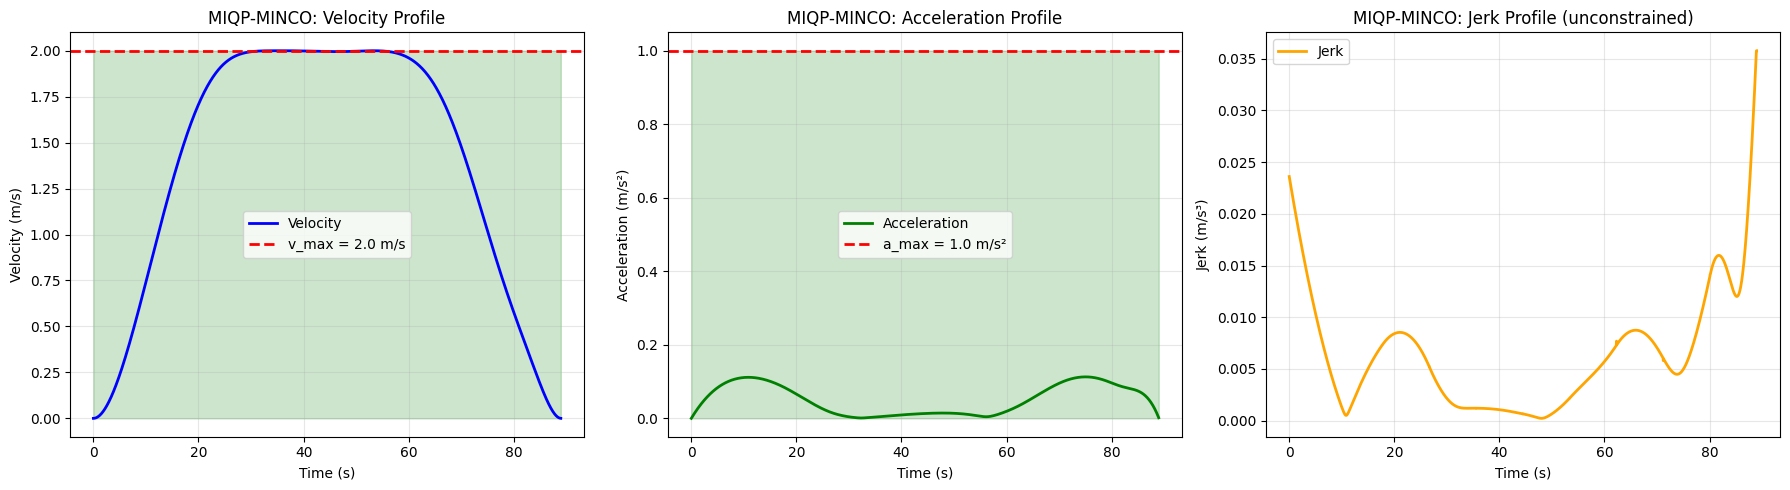

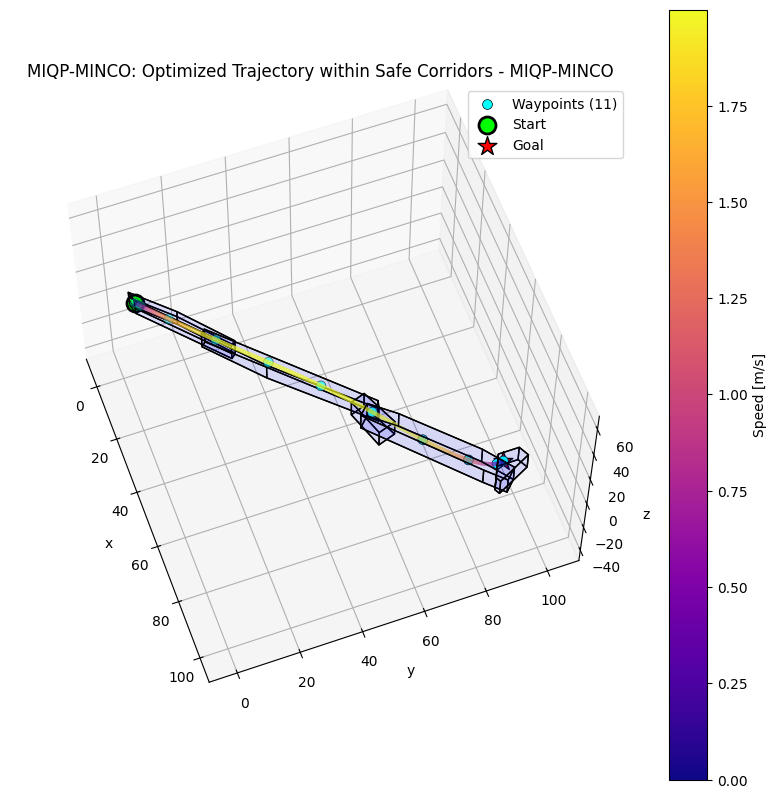

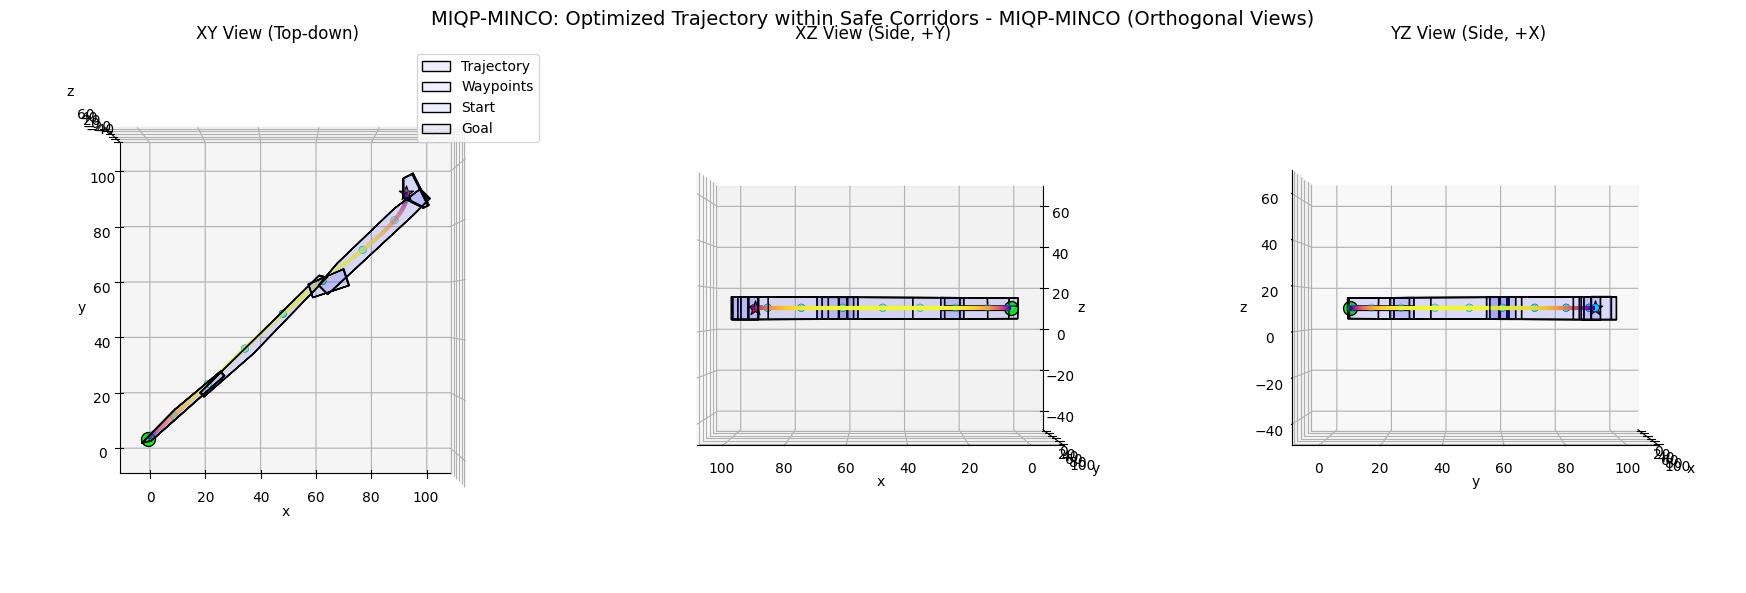

✓ MIQP visualization complete!


In [3]:
##########################################
### STEP 3.1: MIQP - Visualization
##########################################

from miqp_visualizer import visualize_trajectory_3d, visualize_optimization_metrics

print("Generating MIQP-MINCO visualizations...")

# First, extract trajectory from planner
t_eval, pos_eval, vel_eval, acc_eval = planner.get_trajectory(num_samples=200)

# Compute jerk numerically (finite differences)
dt_diff = np.diff(t_eval)
jerk_eval = np.zeros_like(acc_eval)
for i in range(len(dt_diff)):
    if i < len(acc_eval) - 1:
        jerk_eval[i] = (acc_eval[i+1] - acc_eval[i]) / dt_diff[i]
jerk_eval[-1] = jerk_eval[-2]  # Copy last value

# Compute norms
vel_norm = np.linalg.norm(vel_eval, axis=1)
acc_norm = np.linalg.norm(acc_eval, axis=1)
jerk_norm = np.linalg.norm(jerk_eval, axis=1)

# 1) Dynamic constraint profiles (velocity, acceleration, jerk)
# Note: No cost history plots for MIQP (single-shot optimization, not iterative)

visualize_optimization_metrics(
    t_eval=t_eval,
    vel_norm=vel_norm,
    acc_norm=acc_norm,
    jerk_norm=jerk_norm,
    v_max=v_max,
    a_max=a_max,
    method_name="MIQP-MINCO"
)

# 2) 3D trajectory visualization
waypoints_with_boundaries = np.vstack([
    pos_init,
    planner.waypoints,  # From planner object, not results dict
    pos_final
])

visualize_trajectory_3d(
    pos=pos_eval,
    vel=vel_eval,
    A_list=A_list,
    b_list=b_list,
    waypoints=waypoints_with_boundaries,
    start=pos_init,
    goal=pos_final,
    title="MIQP-MINCO: Optimized Trajectory within Safe Corridors",
    method_name="MIQP-MINCO",
    show_orthogonal_views=True
)

print("✓ MIQP visualization complete!")